# NLP con LSTMs — Notebook 1: Datos y Vocabulario
 **Taller SI3014 · TweetEval Sentiment**

 En este notebook construimos toda la infraestructura de datos que usaremos
 en los notebooks 2 y 3:

 1. Carga y exploración del dataset `tweet_eval/sentiment`
 2. Análisis exploratorio (EDA)
 3. Entrenamiento de un tokenizer **WordLevel** desde cero con HuggingFace
 4. Construcción del vocabulario y tokens especiales
 5. `TweetDataset` y `DataLoader` de PyTorch con padding dinámico

 **Clases:** 0 = negative · 1 = neutral · 2 = positive

## 0. Instalación de dependencias

In [2]:
# %%
# # TODO: descomenta si estás en LightningAI / Colab
!pip install datasets tokenizers seaborn wordcloud --quiet

## 1. Imports

In [1]:
import re
import json
from pathlib import Path
from collections import Counter
 
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
 
from datasets import load_dataset
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.trainers import WordLevelTrainer
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.normalizers import Lowercase, NFD, StripAccents, Sequence as NormSequence
 
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
# Reproducibilidad
SEED = 42
torch.manual_seed(SEED)

## 2. Carga del dataset

Usamos `datasets` de HuggingFace. El split ya viene definido:
`train / validation / test`.

In [3]:
dataset = load_dataset("tweet_eval", "sentiment")
print(dataset)
 
# %%
# Veamos algunos ejemplos
for i in range(5):
    example = dataset["train"][i]
    print(f"[{example['label']}] {example['text']}")
    print()

README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
[2] "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"

[1] "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"

[1] Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.

[1] Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays

[2] @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"



## 3. EDA

Antes de modelar, entendemos qué hay en los datos.

       train: {'negative': 7093, 'neutral': 20673, 'positive': 17849}
  validation: {'negative': 312, 'neutral': 869, 'positive': 819}
        test: {'negative': 3972, 'neutral': 5937, 'positive': 2375}


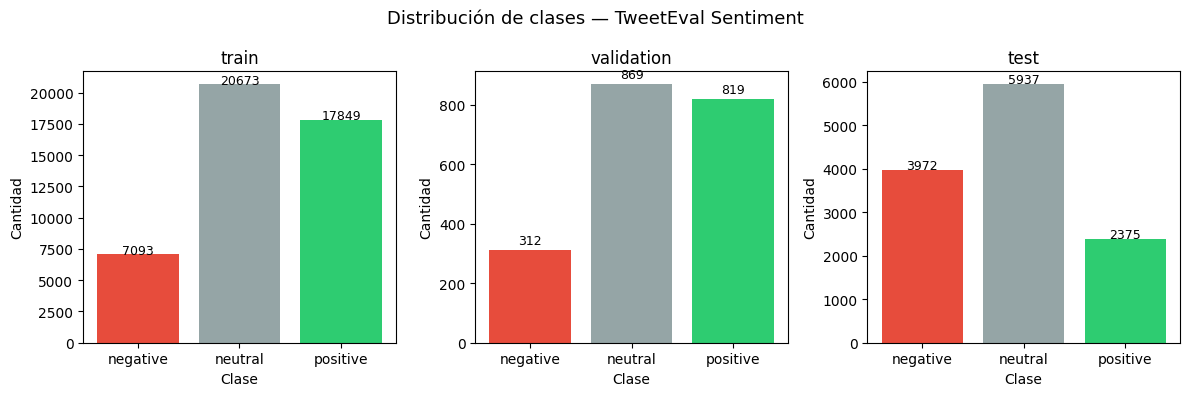

In [4]:
# --- 3.1 Distribución de clases ---
LABEL_NAMES = {0: "negative", 1: "neutral", 2: "positive"}
 
def class_distribution(split_name: str):
    labels = dataset[split_name]["label"]
    counts = Counter(labels)
    return {LABEL_NAMES[k]: counts[k] for k in sorted(counts)}
 
for split in ["train", "validation", "test"]:
    print(f"{split:>12}: {class_distribution(split)}")
 
# %%
# Gráfico de barras por split
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
for ax, split in zip(axes, ["train", "validation", "test"]):
    dist = class_distribution(split)
    ax.bar(dist.keys(), dist.values(), color=["#e74c3c", "#95a5a6", "#2ecc71"])
    ax.set_title(split)
    ax.set_xlabel("Clase")
    ax.set_ylabel("Cantidad")
    for i, (k, v) in enumerate(dist.items()):
        ax.text(i, v + 20, str(v), ha="center", fontsize=9)
plt.suptitle("Distribución de clases — TweetEval Sentiment", fontsize=13)
plt.tight_layout()
plt.show()

> **Observación:** ¿el dataset está balanceado? ¿Qué implicaciones tiene
> esto para la métrica de evaluación que deberíamos usar?

In [ ]:
#--- 3.2 Distribución de longitudes (en tokens) ---
#Hint: usa str.split() para una estimación rápida sin tokenizer
#TODO: calcula la longitud de cada tweet en train
lengths = [...]
#TODO: grafica un histograma con plt.hist(lengths, bins=50)
#Marca con una línea vertical el percentil 95 → eso será MAX_LEN

> **Pregunta:** ¿qué valor de `MAX_LEN` elegirías?
> Recuerda que truncar demasiado pierde información,
> pero un `MAX_LEN` muy grande infla memoria y cómputo.

In [ ]:
MAX_LEN = 50   # TODO: ajusta según tu análisis

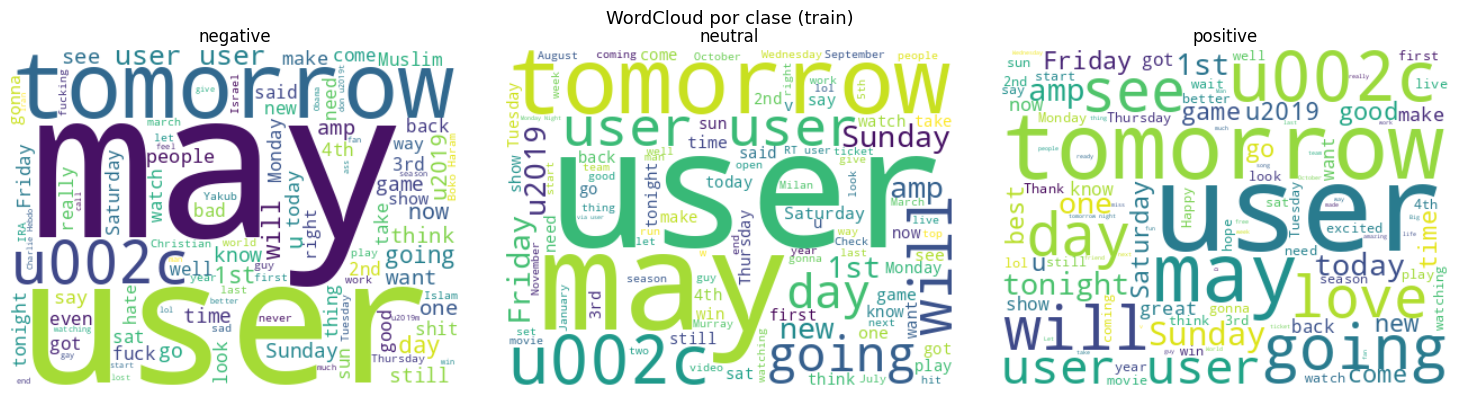

In [5]:
# --- 3.3 WordCloud por clase ---
# (opcional pero bonito para presentaciones)
 
def get_texts_by_label(split_name: str, label: int) -> list[str]:
    return [
        ex["text"] for ex in dataset[split_name]
        if ex["label"] == label
    ]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, label_id, label_name in zip(axes, [0, 1, 2], ["negative", "neutral", "positive"]):
    texts = get_texts_by_label("train", label_id)
    corpus = " ".join(texts)
    wc = WordCloud(width=400, height=300, background_color="white",
                   max_words=100).generate(corpus)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(label_name)
plt.suptitle("WordCloud por clase (train)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Tokenizer WordLevel con HuggingFace
Entrenamos un tokenizer basado en palabras (no BPE, no subwords).
Esto significa que cada token = una palabra del vocabulario.
Pipeline:
```
texto → normalización (lowercase) → split por whitespace → WordLevel vocab
```

In [7]:
# --- 4.1 Función de limpieza básica ---
# Los tweets tienen ruido: URLs, menciones, hashtags, emojis...
# Una limpieza mínima mejora el vocabulario.
 
def clean_tweet(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "<URL>", text)   # URLs → token especial
    text = re.sub(r"@\w+", "<USER>", text)             # menciones → token especial
    text = re.sub(r"#(\w+)", r"\1", text)              # #palabra → palabra (conserva el contenido)
    text = re.sub(r"[^a-z0-9<>\s]", " ", text)        # elimina símbolos y puntuación
    text = re.sub(r"\s+", " ", text).strip()
    return text
 
# Prueba rápida
sample = dataset["train"][0]["text"]
print("Original :", sample)
print("Limpio   :", clean_tweet(sample))

Original : "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Limpio   : qt < > in the original draft of the 7th book remus lupin survived the battle of hogwarts happybirthdayremuslupin


In [9]:
# --- 4.2 Generador de textos limpios para el trainer ---
def tweet_iterator(split_name: str):
    """Genera tweets limpios para entrenar el tokenizer."""
    for ex in dataset[split_name]:
        yield clean_tweet(ex["text"])

In [16]:
# --- 4.3 Construcción y entrenamiento del tokenizer ---

SPECIAL_TOKENS = ["<PAD>", "<UNK>", "<URL>", "<USER>"]
MIN_FREQ = 2        # ignora palabras que aparecen < 2 veces
VOCAB_SIZE = 20_000 # tope máximo; en la práctica quedará mucho menor
MAX_LEN    = 50     # longitud máxima de secuencia (ver análisis p95 arriba)
 
tokenizer = Tokenizer(WordLevel(unk_token="<UNK>"))
 
# Normalización: lowercase + NFD + strip accents
tokenizer.normalizer = NormSequence([NFD(), Lowercase(), StripAccents()])
 
# Pre-tokenizador: split por espacios
tokenizer.pre_tokenizer = Whitespace()
 
trainer = WordLevelTrainer(
    vocab_size=VOCAB_SIZE,
    min_frequency=MIN_FREQ,
    special_tokens=SPECIAL_TOKENS,
)
 
# Entrena SOLO sobre train (nunca uses val/test para construir el vocab)
tokenizer.train_from_iterator(tweet_iterator("train"), trainer=trainer)
 
print(f"Tamaño del vocabulario: {tokenizer.get_vocab_size()}")

Tamaño del vocabulario: 19422


In [17]:
# --- 4.4 Verificación del tokenizer ---
 
sample_clean = clean_tweet(dataset["train"][0]["text"])
encoding = tokenizer.encode(sample_clean)
 
print("Texto   :", sample_clean)
print("Tokens  :", encoding.tokens)
print("IDs     :", encoding.ids)
print()
# TODO: verifica que <PAD> tiene idx=0, <UNK> tiene idx=1
PAD_IDX = tokenizer.token_to_id("<PAD>")
UNK_IDX = tokenizer.token_to_id("<UNK>")
print(f"PAD_IDX={PAD_IDX}  UNK_IDX={UNK_IDX}")

Texto   : qt < > in the original draft of the 7th book remus lupin survived the battle of hogwarts happybirthdayremuslupin
Tokens  : ['qt', '<', '>', 'in', 'the', 'original', 'draft', 'of', 'the', '7th', 'book', 'remus', 'lupin', 'survived', 'the', 'battle', 'of', 'hogwarts', '<UNK>']
IDs     : [9595, 6, 7, 9, 4, 1319, 1790, 13, 4, 302, 423, 7896, 7767, 5387, 4, 1680, 13, 16312, 1]

PAD_IDX=0  UNK_IDX=1


In [18]:
# --- 4.5 Guardar el tokenizer ---
# Lo reutilizaremos en NB2 y NB3
 
TOKENIZER_PATH = "tweet_wordlevel_tokenizer.json"
tokenizer.save(TOKENIZER_PATH)
print(f"Tokenizer guardado en: {TOKENIZER_PATH}")
 
# Para cargar más adelante:
# tokenizer = Tokenizer.from_file(TOKENIZER_PATH)

Tokenizer guardado en: tweet_wordlevel_tokenizer.json


## 5. Dataset y DataLoader de PyTorch
Construimos un `Dataset` que:
- Limpia y tokeniza cada tweet
- Trunca a `MAX_LEN`
- Devuelve tensores de índices + etiqueta
Y un `collate_fn` que hace **padding dinámico** al largo del tweet
más largo del batch (más eficiente que padding estático).
 

In [19]:
class TweetDataset(Dataset):
    """
    Dataset de tweets para clasificación de sentimiento.
 
    Parámetros
    ----------
    hf_split : datasets.Dataset
        Split de HuggingFace (train / validation / test).
    tokenizer : Tokenizer
        Tokenizer WordLevel entrenado.
    max_len : int
        Longitud máxima de la secuencia (trunca si es mayor).
    """
 
    def __init__(self, hf_split, tokenizer, max_len: int = MAX_LEN):
        self.data = hf_split
        self.tokenizer = tokenizer
        self.max_len = max_len
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        example = self.data[idx]
        text = clean_tweet(example["text"])
        label = example["label"]
 
        # tokeniza `text` con self.tokenizer.encode(text).ids
        # trunca a self.max_len
        # convierte a torch.tensor (dtype=torch.long)
        ids = self.tokenizer.encode(text).ids[:self.max_len]
        ids_tensor = torch.tensor(ids, dtype=torch.long)
        label_tensor = torch.tensor(label, dtype=torch.long)
 
        return ids_tensor, label_tensor
 
 
# --- Collate fn: padding dinámico ---
 
def collate_fn(batch):
    """
    Recibe una lista de (ids_tensor, label_tensor).
    Aplica padding hasta el largo máximo del batch.
    """
    sequences, labels = zip(*batch)
 
    # TODO: usa pad_sequence para hacer padding
    # Hint: pad_sequence(sequences, batch_first=True, padding_value=PAD_IDX)
    padded = pad_sequence(sequences, batch_first=True, padding_value=PAD_IDX)
    labels = torch.stack(labels)
 
    return padded, labels

In [20]:
# --- Instanciar datasets ---
 
train_dataset = TweetDataset(dataset["train"], tokenizer)
val_dataset   = TweetDataset(dataset["validation"], tokenizer)
test_dataset  = TweetDataset(dataset["test"], tokenizer)
 
print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
 
# %%
# --- DataLoaders ---
 
BATCH_SIZE = 64
 
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)
 

Train: 45,615 | Val: 2,000 | Test: 12,284


In [21]:
# --- Verificación del DataLoader ---
batch_ids, batch_labels = next(iter(train_loader))
print(f"batch_ids shape   : {batch_ids.shape}")    # (BATCH_SIZE, seq_len_max_en_batch)
print(f"batch_labels shape: {batch_labels.shape}") # (BATCH_SIZE,)
print(f"Etiquetas en batch: {batch_labels[:10].tolist()}")

batch_ids shape   : torch.Size([64, 29])
batch_labels shape: torch.Size([64])
Etiquetas en batch: [2, 2, 0, 1, 1, 2, 1, 2, 0, 1]


> **Pregunta de cierre:**
> - ¿Por qué hacemos padding dinámico en lugar de padding estático a `MAX_LEN`?
> - ¿Por qué el tokenizer se entrena **solo** sobre `train` y no sobre todo el corpus?
> - ¿Qué riesgo hay si incluimos `val` o `test` al construir el vocab?

## 6. Resumen y artefactos generados
Al finalizar este notebook tienes:
| Artefacto | Descripción |
|---|---|
| `tweet_wordlevel_tokenizer.json` | Tokenizer WordLevel serializado |
| `train_loader` | DataLoader listo para NB2 |
| `val_loader` | DataLoader de validación |
| `test_loader` | DataLoader de test |
| `PAD_IDX`, `UNK_IDX` | Índices especiales para el modelo |
| `VOCAB_SIZE` efectivo | `tokenizer.get_vocab_size()` |
En **NB2** construiremos el modelo LSTM simple usando estos artefactos.

In [23]:
# Guardamos constantes que NB2 necesita (opcional, también se pueden re-calcular)
config = {
    "vocab_size": tokenizer.get_vocab_size(),
    "pad_idx": PAD_IDX,
    "unk_idx": UNK_IDX,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "num_classes": 3,
    "label_names": LABEL_NAMES,
}
with open("nb1_config.json", "w") as f:
    json.dump(config, f, indent=2)
 
print("Config guardada en nb1_config.json")
print(json.dumps(config, indent=2))

Config guardada en nb1_config.json
{
  "vocab_size": 19422,
  "pad_idx": 0,
  "unk_idx": 1,
  "max_len": 50,
  "batch_size": 64,
  "num_classes": 3,
  "label_names": {
    "0": "negative",
    "1": "neutral",
    "2": "positive"
  }
}
